In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from eplot import eplot

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
dir = "/Users/wangshuaibo/我的资料库/1项目/项目进行时/北京悦动/脑卒中项目/阿帅笔记/测试数据及分析结果/HarbinStroke/Xsens/Process_Data/Excel"

In [3]:
os.chdir(dir)
os.getcwd()

'/Users/wangshuaibo/我的资料库/1项目/项目进行时/北京悦动/脑卒中项目/阿帅笔记/测试数据及分析结果/HarbinStroke/Xsens/Process_Data/Excel'

In [ ]:
filename = "20230716_杜金良_Xsens_穿鞋无绷带-2.xlsx"
free_acc_df = pd.read_excel(filename, sheet_name='Sensor Free Acceleration')
left_foot_accs = free_acc_df[["Left Foot x",	"Left Foot y",	"Left Foot z"]]
right_foot_accs = free_acc_df[["Right Foot x",	"Right Foot y",	"Right Foot z"]]

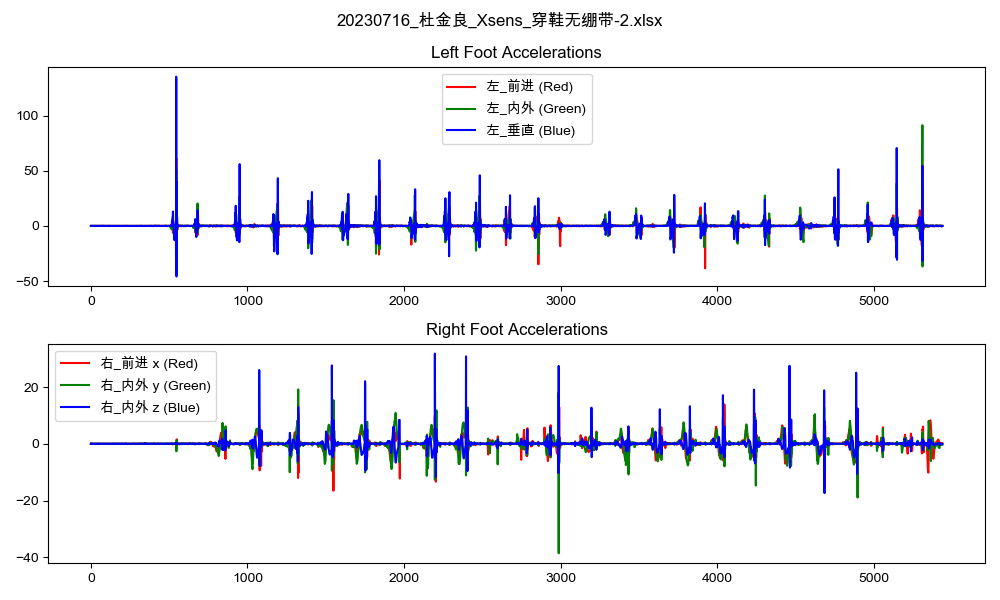

In [42]:
plt.close()

# 绘制左脚的加速度数据
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)  # 两行一列，这是第一个图
plt.plot(left_foot_accs["Left Foot x"], 'r', label='左_前进 (Red)')
plt.plot(left_foot_accs["Left Foot y"], 'g', label='左_内外 (Green)')
plt.plot(left_foot_accs["Left Foot z"], 'b', label='左_垂直 (Blue)')
plt.title('Left Foot Accelerations')
plt.legend()

# 绘制右脚的加速度数据
plt.subplot(2, 1, 2)  # 两行一列，这是第二个图
plt.plot(right_foot_accs["Right Foot x"], 'r', label='右_前进 x (Red)')
plt.plot(right_foot_accs["Right Foot y"], 'g', label='右_内外 y (Green)')
plt.plot(right_foot_accs["Right Foot z"], 'b', label='右_内外 z (Blue)')
plt.title('Right Foot Accelerations')
plt.legend()

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # 设置中文
plt.suptitle(filename)

# 显示图表
plt.tight_layout()
plt.show()

In [22]:
euler_df = pd.read_excel(filename, sheet_name='Sensor Orientation - Euler')

In [23]:
left_foot_eulers = euler_df[["Left Foot x",	"Left Foot y",	"Left Foot z"]]
right_foot_eulers = euler_df[["Right Foot x",	"Right Foot y",	"Right Foot z"]]

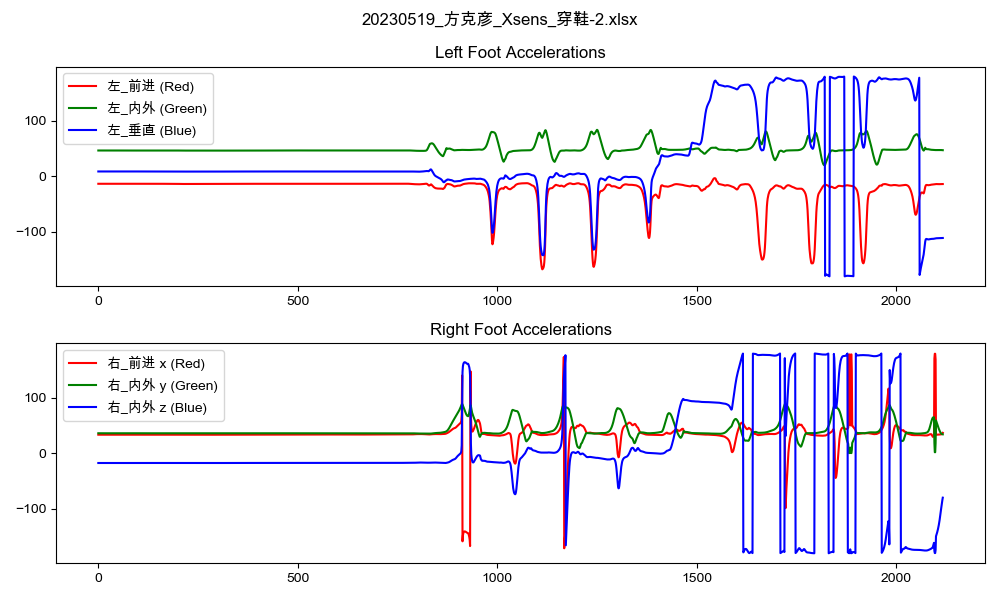

In [24]:
plt.close()

# 绘制左脚的加速度数据
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)  # 两行一列，这是第一个图
plt.plot(left_foot_eulers["Left Foot x"], 'r', label='左_前进 (Red)')
plt.plot(left_foot_eulers["Left Foot y"], 'g', label='左_内外 (Green)')
plt.plot(left_foot_eulers["Left Foot z"], 'b', label='左_垂直 (Blue)')
plt.title('Left Foot Accelerations')
plt.legend()

# 绘制右脚的加速度数据
plt.subplot(2, 1, 2)  # 两行一列，这是第二个图
plt.plot(right_foot_eulers["Right Foot x"], 'r', label='右_前进 x (Red)')
plt.plot(right_foot_eulers["Right Foot y"], 'g', label='右_内外 y (Green)')
plt.plot(right_foot_eulers["Right Foot z"], 'b', label='右_内外 z (Blue)')
plt.title('Right Foot Accelerations')
plt.legend()

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # 设置中文
plt.suptitle(filename)

# 显示图表
plt.tight_layout()
plt.show()

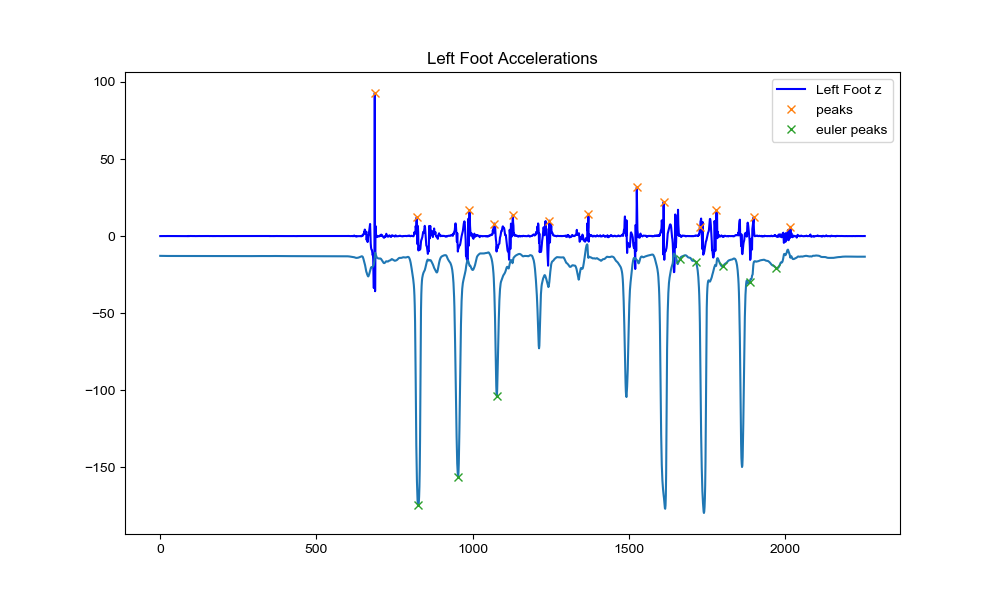

In [14]:
plt.close()
left_foot_accs["Left Foot z"].plot()

import scipy.signal as signal
import numpy as np

plt.close()
# 查找峰值
peaks, _ = signal.find_peaks(left_foot_accs["Left Foot z"], 
                             height=5, 
                             distance=50)
euler_peaks, _ = signal.find_peaks(-left_foot_eulers["Left Foot z"],
                                   height=50,
                                   distance=50)

# 绘制原始数据
plt.figure(figsize=(10, 6))
plt.plot(left_foot_accs["Left Foot z"], 'b', label='Left Foot z')
plt.plot(left_foot_eulers["Left Foot x"])
plt.title('Left Foot Accelerations')

# 绘制峰值
plt.plot(peaks, left_foot_accs["Left Foot z"][peaks], "x", label='peaks')
plt.plot(euler_peaks, left_foot_eulers["Left Foot x"][euler_peaks], "x", label='euler peaks')
plt.legend()


In [65]:
import plotly
import plotly.graph_objects as go

# 定义每个系列的数据
series1 = go.Scatter(x=left_foot_accs["Left Foot z"].index, 
                     y=left_foot_accs["Left Foot z"], 
                     name='自由加速度 z')
series2 = go.Scatter(x=left_foot_eulers["Left Foot z"].index, 
                     y=left_foot_eulers["Left Foot z"], 
                     name='欧拉角 z')
series3 = go.Scatter(x=peaks,
                        y=left_foot_accs["Left Foot z"][peaks],
                        name='峰值',
                        mode='markers',
                        marker=dict(symbol="x",
                                    size=5,
                                    color="red"))

# 创建并显示图形
fig = go.Figure(data=[series1, series2, series3])
fig.update_layout(title=filename) # 设置图形标题
x_values = [50, 100 ,1000]

for x in x_values:
    fig.add_shape(
        type="line",
        x0=x,
        y0=0,
        x1=x,
        y1=1,
        yref="paper", # 相对于画布的高度
        line=dict(
            color="RoyalBlue",
            width=0.5,
            dash="dashdot", # 点划线
        )
    )
fig.show()

#plotly.offline.plot(fig, filename='left_foot_accs.html')

In [66]:
from plotly.subplots import make_subplots

# 创建一个包含两个子图的图形
fig = make_subplots(rows=2, cols=1, shared_xaxes=True)

# 添加数据到第一个子图
fig.add_trace(series1, row=1, col=1)

# 添加数据到第二个子图
fig.add_trace(series2, row=2, col=1)

x_values = [50, 100, 1000]

for x in x_values:
    # 添加垂直线，这些线会在所有的子图上显示
    fig.add_shape(
        type="line",
        x0=x,
        y0=0,
        x1=x,
        y1=1,
        yref="paper",  # 相对于画布的高度
        line=dict(
            color="RoyalBlue",
            width=0.5,
            dash="dashdot",  # 点划线
        )
    )

fig.show()